# =================================================================
# SECTION A: IMPORTING LIBRARIES
# =================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os

# Start Timer
start = time.time()

# Kaggle input and output paths
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
INPUT_PATH = "/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/"
PATH = "/kaggle/working/"

# Reading CSV File
data = pd.read_csv(os.path.join(INPUT_PATH, "zomato.csv"))

/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv


# =================================================================
# SECTION B: DATA_EXPLORATION
# =================================================================

In [2]:
print("<----------DATA_EXPLORATION---------->")

head = data.head(10)
print("First 10 Rows of the DATA_SET\n", head)

tail = data.tail(10)
print("Last 10 Rows of the DATA_SET\n", tail)

info = data.info()
print("Information of the DATA_SET\n", info)

describe = data.describe()
print('Descriptive Statistics of the DATA_SET\n', describe)

shape = data.shape
print("Shape of the DATA_SET\n", shape)

size = data.size
print("Size of the DATA_SET\n", size)

columns = data.columns
print("Columns Names of the DATA_SET\n", columns)

Sum_Of_the_Null_Values = data.isnull().sum()
print("Sum of Null Values per Column\n", Sum_Of_the_Null_Values)

Total_Sum_Of_the_Null_Values = data.isnull().sum().sum()
print("Total Null Values\n", Total_Sum_Of_the_Null_Values)

null_percentage = data.isnull().mean() * 100
print("Null Percentage per Column\n", null_percentage)

Total_Percentage_of_Null_Values = (data.isnull().sum().sum() / data.size) * 100
print("Total Null Percentage\n", Total_Percentage_of_Null_Values)

Sum_of_the_Duplicate_Values = data.duplicated().sum()
print("Total Duplicate Rows\n", Sum_of_the_Duplicate_Values)

Unique_Values = data.nunique()
print("Unique Values per Column\n", Unique_Values)

<----------DATA_EXPLORATION---------->
First 10 Rows of the DATA_SET
                                                  url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   
5  https://www.zomato.com/bangalore/timepass-dinn...   
6  https://www.zomato.com/bangalore/rosewood-inte...   
7  https://www.zomato.com/bangalore/onesta-banash...   
8  https://www.zomato.com/bangalore/penthouse-caf...   
9  https://www.zomato.com/bangalore/smacznego-ban...   

                                             address  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...   
2  1112, Next to KIMS Medical College, 17th Cross...   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...   
4  10, 3rd Floor, Lakshmi Associa

# =================================================================
# SECTION C: DATA_CLEANING
# =================================================================

In [3]:
print("<----------DATA_CLEANING---------->")

data.drop_duplicates(inplace=True)
data.drop(['phone', 'dish_liked'], axis=1, inplace=True)
data.dropna(subset=['location', 'rest_type', 'cuisines', 'approx_cost(for two people)'], axis=0, inplace=True)

data['rate'] = data['rate'].apply(lambda x: str(x).split('/')[0])
data['rate'] = pd.to_numeric(data['rate'], errors='coerce')

data['rate'] = data['rate'].fillna(data.groupby(['rest_type', 'location'])['rate'].transform('median'))
data['rate'] = data['rate'].fillna(data['rate'].median())
data['rate'] = data['rate'].round(1).astype('float16')

data['votes'] = data['votes'].astype('int32')
data['online_order'] = data['online_order'].astype('category')
data['book_table'] = data['book_table'].astype('category')

data['approx_cost(for two people)'] = data['approx_cost(for two people)'].astype(str).str.replace(',', '')
data['approx_cost(for two people)'] = pd.to_numeric(data['approx_cost(for two people)'], errors='coerce').astype('float32')
data.rename(columns={"approx_cost(for two people)": "cost_for_two"}, inplace=True)

print("<--- Dataset Summary after Cleaning --->")
print(data.info())

<----------DATA_CLEANING---------->
<--- Dataset Summary after Cleaning --->
<class 'pandas.core.frame.DataFrame'>
Index: 51148 entries, 0 to 51716
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   url              51148 non-null  object  
 1   address          51148 non-null  object  
 2   name             51148 non-null  object  
 3   online_order     51148 non-null  category
 4   book_table       51148 non-null  category
 5   rate             51148 non-null  float16 
 6   votes            51148 non-null  int32   
 7   location         51148 non-null  object  
 8   rest_type        51148 non-null  object  
 9   cuisines         51148 non-null  object  
 10  cost_for_two     51148 non-null  float32 
 11  reviews_list     51148 non-null  object  
 12  menu_item        51148 non-null  object  
 13  listed_in(type)  51148 non-null  object  
 14  listed_in(city)  51148 non-null  object  
dtypes: category(2),

# =================================================================
# SECTION D: SAVING PROCESSED FILES
# =================================================================

In [4]:
data.to_csv(os.path.join(PATH, "zomato_cleaned.csv"), index=False)
print("Cleaned CSV saved successfully")

Cleaned CSV saved successfully


# =================================================================
# SECTION E: CREATING DATA SUBSET
# =================================================================

In [5]:
warnings.filterwarnings('ignore')

sub_set = data[['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'cost_for_two']].copy()
print(sub_set.head())

sub_set.to_csv(os.path.join(PATH, "zomato_SubSet.csv"), index=False)
print("SubSet CSV saved successfully")

                    name online_order book_table      rate  votes  \
0                  Jalsa          Yes        Yes  4.101562    775   
1         Spice Elephant          Yes         No  4.101562    787   
2        San Churro Cafe          Yes         No  3.800781    918   
3  Addhuri Udupi Bhojana           No         No  3.699219     88   
4          Grand Village           No         No  3.800781    166   

       location  cost_for_two  
0  Banashankari         800.0  
1  Banashankari         800.0  
2  Banashankari         800.0  
3  Banashankari         300.0  
4  Basavanagudi         600.0  
SubSet CSV saved successfully


# =================================================================
# SECTION F: INSIGHTS
# =================================================================

In [6]:
# Que 1: Value for Money Restaurants
VFM = sub_set[(sub_set['rate'] > 4.0) & (sub_set['cost_for_two'] < 500)]
VFM_top = VFM.sort_values('votes', ascending=False).head(10)
print("Value for Money Restaurants (Top 10):")
print(VFM_top[['name', 'location', 'rate', 'cost_for_two', 'votes']])

# Que 2: Top 10 Locations by Average Rating
location_rating = sub_set.groupby('location')['rate'].mean()
print("\nTop 10 Locations by Average Rating:")
print(location_rating.sort_values(ascending=False).head(10))

# Que 3: Online Order Impact on Ratings
online_impact = sub_set.groupby('online_order')['rate'].mean()
print("\nAverage Rating: Online vs Offline:")
print(online_impact)

# Que 4: Total Votes
total_votes = sub_set['votes'].sum()
print("\nTotal Votes:", total_votes)

# Que 5: Average Cost for Two
avg_cost = sub_set['cost_for_two'].mean()
print("Average Cost for Two:", round(avg_cost, 2))

# Que 6: Location Summary
location_summary = sub_set.groupby('location').agg({
    'rate': 'mean',
    'cost_for_two': 'mean',
    'votes': 'sum'
}).reset_index()
print("\nLocation Summary:")
print(location_summary)

Value for Money Restaurants (Top 10):
                   name               location      rate  cost_for_two  votes
3337   Vidyarthi Bhavan           Basavanagudi  4.398438         150.0   4460
769    Vidyarthi Bhavan           Basavanagudi  4.398438         150.0   4460
46445               CTR           Malleshwaram  4.800781         150.0   4421
46973               CTR           Malleshwaram  4.800781         150.0   4421
39518               CTR           Malleshwaram  4.699219         150.0   4408
40161               CTR           Malleshwaram  4.699219         150.0   4408
36921      Kota Kachori  Koramangala 6th Block  4.300781         400.0   3624
33863      Kota Kachori  Koramangala 6th Block  4.300781         400.0   3621
34961      Kota Kachori  Koramangala 6th Block  4.300781         400.0   3621
31448      Kota Kachori  Koramangala 6th Block  4.300781         400.0   3618

Top 10 Locations by Average Rating:
location
Lavelle Road             4.119328
St. Marks Road          

# =================================================================
# SECTION G: VISUALISATIONS
# =================================================================

In [7]:
# Chart 1: Votes Distribution
def plot_pro_bar(df):
    sns.set_theme(context='talk', style='white', palette='viridis',
                  rc={"axes.spines.right": False, "axes.spines.top": False})
    fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
    sns.barplot(data=df, x="online_order", y="votes", hue="book_table",
                estimator='mean', errorbar=('ci', 95), capsize=0.1, alpha=0.85, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=6, fontsize=10, fontweight='medium')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    overall_avg = df["votes"].mean()
    ax.axhline(overall_avg, color='#e74c3c', linestyle='--', linewidth=1.5, label='Global Avg', alpha=0.7)
    ax.set_title("Votes Distribution by Online Order & Table Booking", loc='left', fontsize=20, pad=20, fontweight='bold')
    ax.set_xlabel("Online Order", fontsize=12, labelpad=10)
    ax.set_ylabel("Mean Votes", fontsize=12, labelpad=10)
    ax.legend(title="Book Table", frameon=False, loc='best')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "votes_online_booktable.png"), dpi=150, bbox_inches="tight")
    print("Chart 1 saved")
    plt.show()
    plt.close()

# Chart 2: Ratings Distribution
def plot_pro_hist(df):
    sns.set_theme(style="white", context="talk",
                  rc={"axes.spines.right": False, "axes.spines.top": False})
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    sns.histplot(data=df, x="rate", hue="online_order", bins=25,
                 multiple='dodge', stat='percent', common_norm=False,
                 kde=True, palette='viridis', shrink=0.8, alpha=0.6, ax=ax)
    for container in ax.containers:
        if hasattr(container, '__iter__'):
            ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=9, fontweight='semibold')
    mean_val = df["rate"].mean()
    ax.axvline(mean_val, color='#d35400', linestyle='--', linewidth=2, alpha=0.8)
    ax.text(mean_val + 0.05, ax.get_ylim()[1] * 0.9, "Avg: {:.2f}".format(mean_val),
            color='#d35400', fontweight='bold', fontsize=11)
    ax.set_title("Ratings Benchmarking by Online Order", loc='left', fontsize=20, pad=25, fontweight='bold')
    ax.set_xlabel("Rating", fontsize=13, labelpad=12)
    ax.set_ylabel("Proportion of Restaurants (%)", fontsize=13, labelpad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "ratings_distribution.png"), dpi=150, bbox_inches="tight")
    print("Chart 2 saved")
    plt.show()
    plt.close()

# Chart 3: Votes vs Ratings Scatter
def plot_pro_scatter(df):
    sns.set_theme(style="ticks", context="talk")
    fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
    sns.scatterplot(data=df, x="votes", y="rate", hue="online_order",
                    size="book_table", sizes=(40, 400), alpha=0.6,
                    edgecolor='white', linewidth=0.5, palette='viridis', ax=ax)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    mean_x = df["votes"].mean()
    mean_y = df["rate"].mean()
    ax.axvline(mean_x, color='grey', linestyle=':', alpha=0.6)
    ax.axhline(mean_y, color='grey', linestyle=':', alpha=0.6)
    ax.text(0.92, 0.95, 'Top Performers', transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='#2c3e50', alpha=0.75, ha='right', va='top')
    ax.set_title("Correlation: Votes vs. Ratings", loc='left', fontsize=20, pad=20, fontweight='bold')
    ax.set_xlabel("Votes", fontsize=14, labelpad=10)
    ax.set_ylabel("Ratings", fontsize=14, labelpad=10)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "votes_vs_ratings.png"), dpi=150, bbox_inches="tight")
    print("Chart 3 saved")
    plt.show()
    plt.close()

# Chart 4: Cuisine Distribution
def plot_pro_count(df):
    sns.set_theme(style="white", context="talk")
    fig, ax = plt.subplots(figsize=(16, 8), dpi=100)
    cuisine_series = df["cuisines"].dropna().str.split(',').explode().str.strip()
    top_15_cuisines = cuisine_series.value_counts().head(15).index.tolist()
    df_filtered = df[df["cuisines"].isin(top_15_cuisines)].copy()
    df_filtered["cuisines"] = df_filtered["cuisines"].str.split(',').str[0].str.strip()
    sns.countplot(data=df_filtered, x="cuisines", hue="online_order",
                  order=top_15_cuisines, palette='viridis', alpha=0.85, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9, fontweight='semibold')
    ax.set_title("Cuisine Distribution by Online Order", loc='left', fontsize=20, pad=25, fontweight='bold')
    ax.set_xlabel("Cuisine Type", fontsize=14, labelpad=12)
    ax.set_ylabel("Number of Restaurants", fontsize=14, labelpad=12)
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "cuisine_distribution.png"), dpi=150, bbox_inches="tight")
    print("Chart 4 saved")
    plt.show()
    plt.close()

# Chart 5: Correlation Heatmap
def plot_pro_corr(df):
    sns.set_theme(style="white", context="talk")
    corr = df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', vmax=1, vmin=-1, center=0,
                annot=True, fmt='.2f', square=True, linewidths=.8,
                cbar_kws={"shrink": .7, "label": "Pearson Correlation Coefficient"}, ax=ax)
    ax.set_title("Feature Correlation: Identifying Multi-collinearity",
                 loc='left', fontsize=20, fontweight='bold', pad=30)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(PATH, "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
    print("Chart 5 saved")
    plt.show()
    plt.close()

# =================================================================
# SECTION H: FINAL EXECUTION
# =================================================================


[PROCESS] Generating charts...
Chart 1 saved


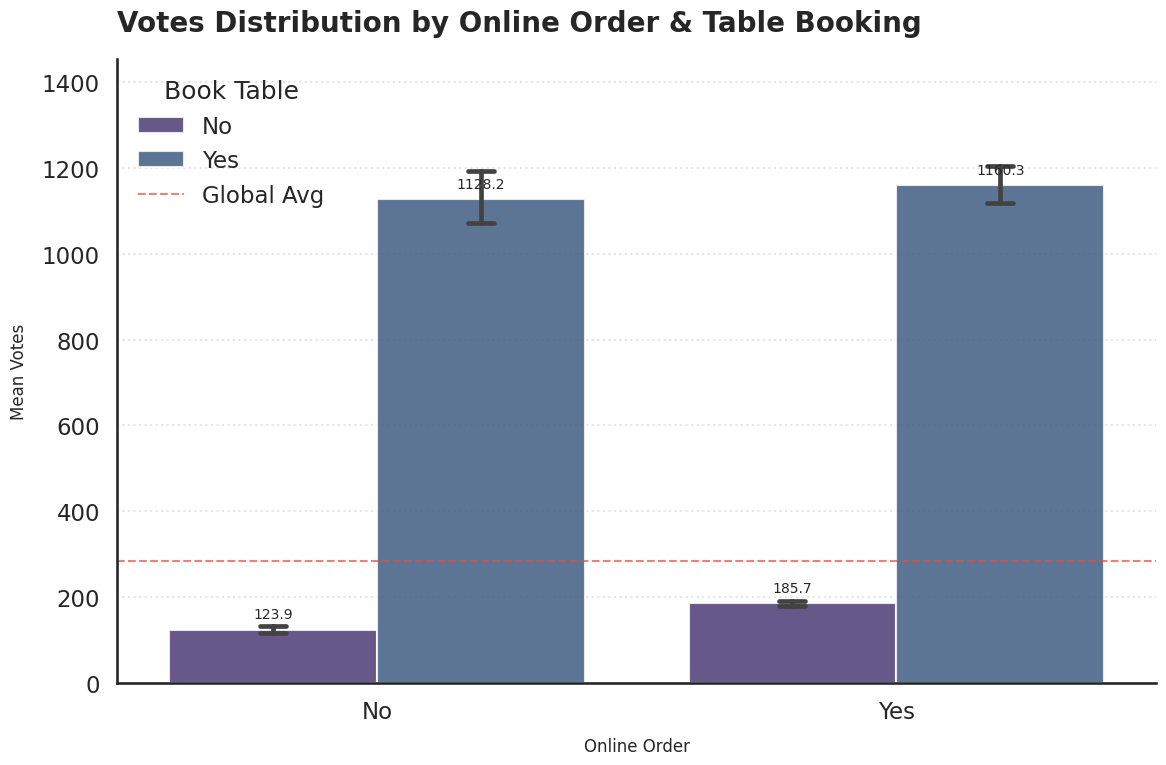

Chart 2 saved


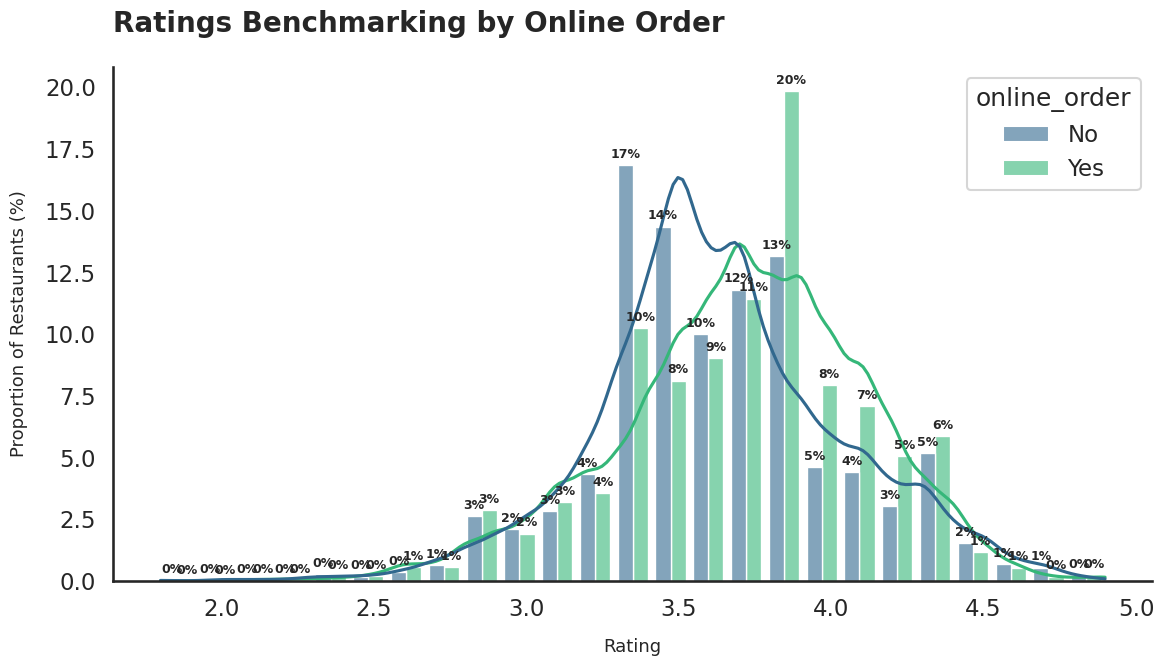

Chart 3 saved


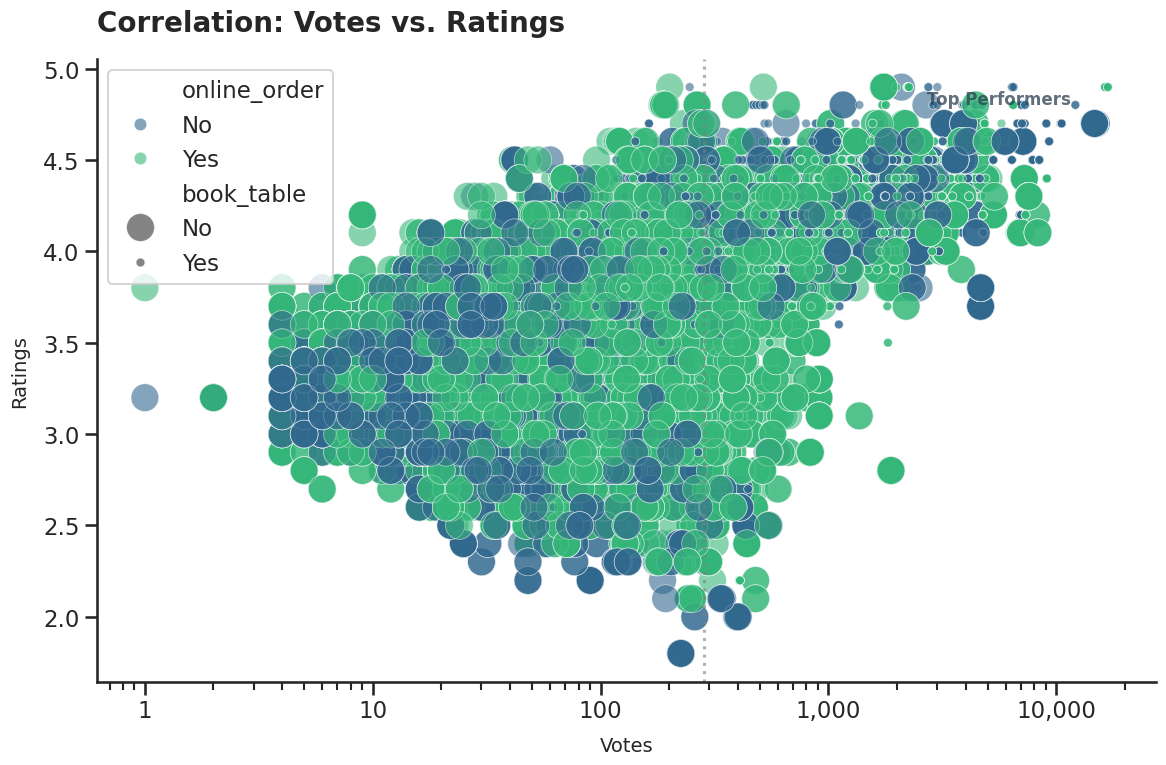

Chart 4 saved


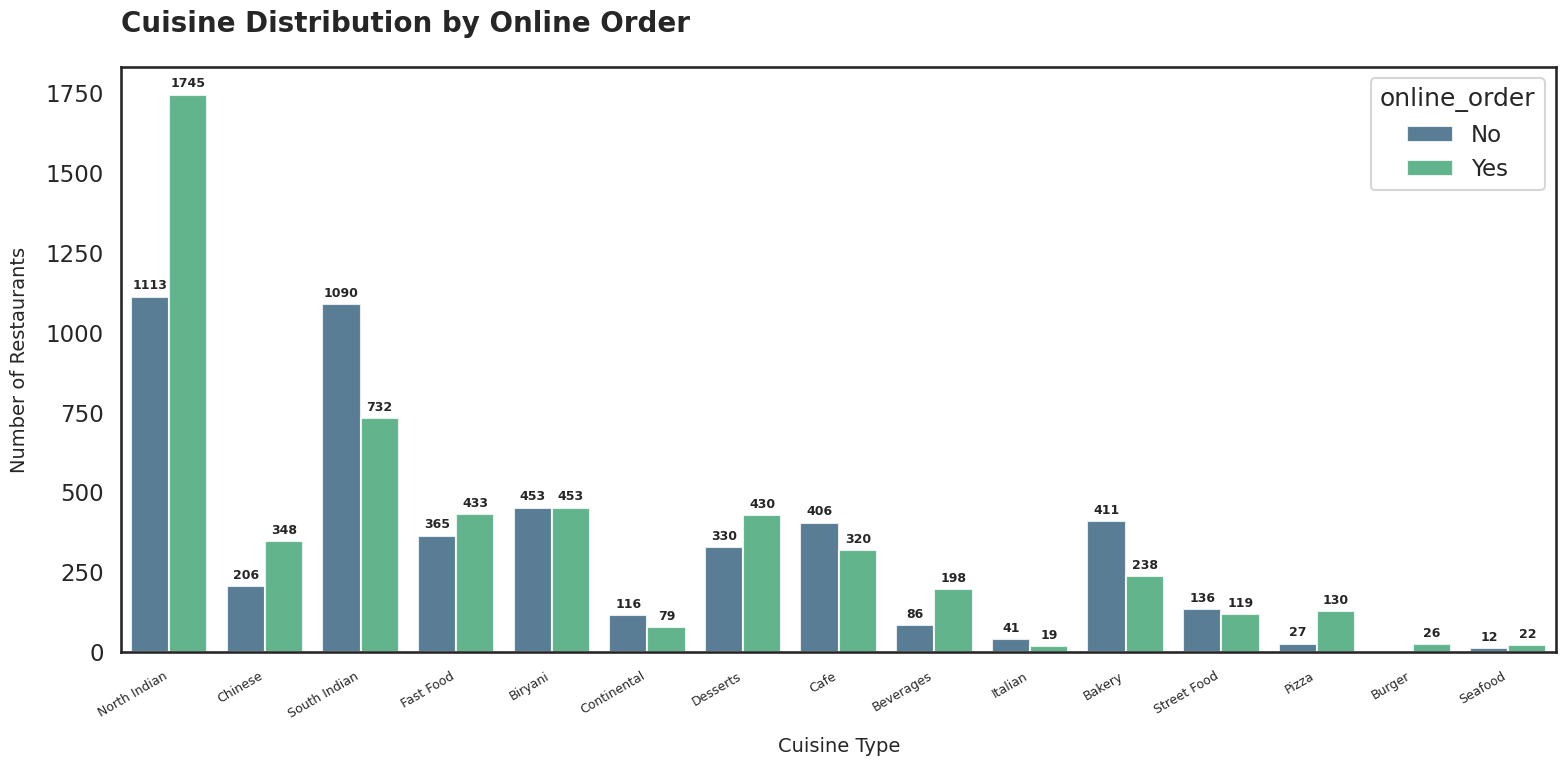

Chart 5 saved


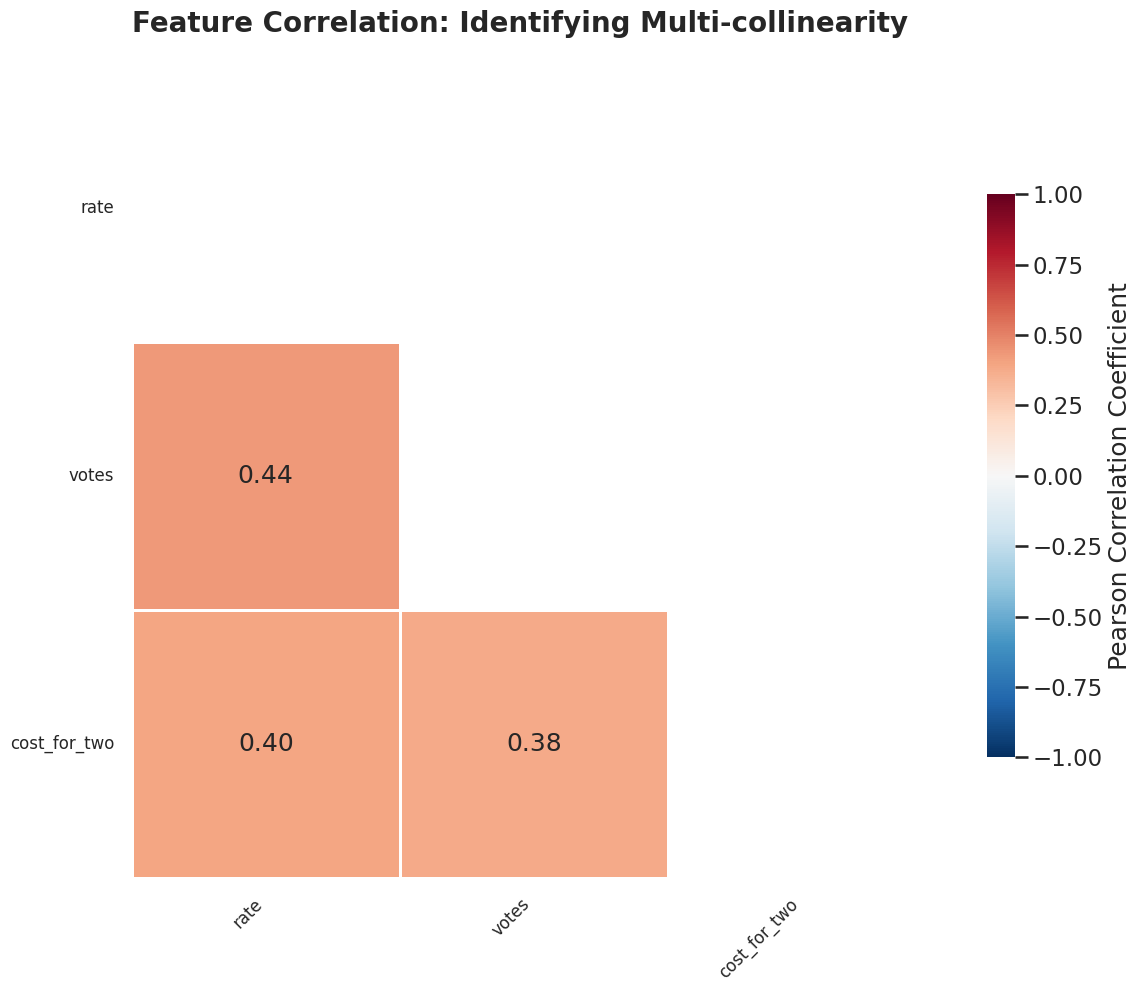

[DONE] All 5 charts saved!
Total Time: 44.1308 seconds


In [8]:
print("\n[PROCESS] Generating charts...")

plot_pro_bar(sub_set)
plot_pro_hist(sub_set)
plot_pro_scatter(sub_set)
plot_pro_count(data)
plot_pro_corr(sub_set)

print("[DONE] All 5 charts saved!")

end = time.time()
print(f"Total Time: {end - start:.4f} seconds")